In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("exoplanet_raw.csv")

In [4]:
df.head()

,pl_name,hostname,pl_rade,pl_masse,pl_orbper,pl_orbsmax,pl_eqt,pl_insol,st_teff,st_mass,st_rad,sy_snum,sy_pnum,discoverymethod,disc_year
0,HD 2039 b,HD 2039,12.700000,NaN,1120.000000,2.20000,210.84,0.3229,5945.0,1.230,1.190,1,1,Radial Velocity,2002
1,HAT-P-8 b,HAT-P-8,15.692600,406.8224,3.076340,0.04496,1713.00,1519.9645,6200.0,1.270,1.570,3,1,Transit,2008
2,K2-43 b,K2-43,4.510000,NaN,3.471149,0.03784,939.30,49.0000,3840.6,0.571,0.542,1,2,Transit,2016
3,Kepler-1753 b,Kepler-1753,2.226781,NaN,16.004601,0.11790,583.00,27.4100,5180.0,0.860,0.769,1,1,Transit,2021
4,Kepler-1176 b,Kepler-1176,2.450000,NaN,24.173858,0.15890,595.00,26.0870,5844.0,1.010,1.020,1,1,Transit,2016


In [8]:
df.shape

(6360, 15)

In [6]:
df.columns

Index(['pl_name', 'hostname', 'pl_rade', 'pl_masse', 'pl_orbper', 'pl_orbsmax',
       'pl_eqt', 'pl_insol', 'st_teff', 'st_mass', 'st_rad', 'sy_snum',
       'sy_pnum', 'discoverymethod', 'disc_year'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6360 entries, 0 to 6359
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   pl_name          6360 non-null   object 
 1   hostname         6360 non-null   object 
 2   pl_rade          6310 non-null   float64
 3   pl_masse         2448 non-null   float64
 4   pl_orbper        6014 non-null   float64
 5   pl_orbsmax       5930 non-null   float64
 6   pl_eqt           5830 non-null   float64
 7   pl_insol         5774 non-null   float64
 8   st_teff          6060 non-null   float64
 9   st_mass          6351 non-null   float64
 10  st_rad           6036 non-null   float64
 11  sy_snum          6360 non-null   int64  
 12  sy_pnum          6360 non-null   int64  
 13  discoverymethod  6360 non-null   object 
 14  disc_year        6360 non-null   int64  
dtypes: float64(9), int64(3), object(3)
memory usage: 745.4+ KB


In [16]:
df.isna().sum()

pl_name               0
hostname              0
pl_rade              50
pl_masse           3912
pl_orbper           346
pl_orbsmax          430
pl_eqt              530
pl_insol            586
st_teff             300
st_mass               9
st_rad              324
sy_snum               0
sy_pnum               0
discoverymethod       0
disc_year             0
dtype: int64

In [17]:
df.describe()

,pl_rade,pl_masse,pl_orbper,pl_orbsmax,pl_eqt,pl_insol,st_teff,st_mass,st_rad,sy_snum,sy_pnum,disc_year
count,6310.000000,2448.000000,6.014000e+03,5930.000000,5830.000000,5774.000000,6060.000000,6351.000000,6036.000000,6360.000000,6360.000000,6360.000000
mean,5.869331,810.119432,7.118441e+04,15.478675,835.069503,534.042241,5393.014279,0.934429,1.488508,1.102516,1.759434,2017.280189
std,5.427364,1589.169007,5.186180e+06,346.210088,496.523649,9930.761414,1726.420239,0.386977,3.858358,0.340937,1.150831,5.136457
min,0.309800,0.020000,9.070629e-02,0.004400,1.480000,0.000000,415.000000,0.009400,0.011500,1.000000,1.000000,1992.000000
25%,1.850000,11.387500,4.303691e+00,0.052300,485.895000,10.054075,4898.000000,0.770000,0.770000,1.000000,1.000000,2014.000000
50%,2.870000,159.295330,1.072626e+01,0.102700,756.000000,65.715950,5544.000000,0.940000,0.950000,1.000000,1.000000,2016.000000
75%,11.948789,721.471388,3.857165e+01,0.310250,1093.000000,280.404500,5899.250000,1.087500,1.250000,1.000000,2.000000,2021.000000
max,87.205870,9534.852210,4.020000e+08,19000.000000,7777.780000,636352.125800,57000.000000,9.100000,88.475000,4.000000,8.000000,2026.000000


In [6]:
df = df.rename(columns={
    "pl_name": "planet_name",
    "hostname": "host_star",
    "pl_rade": "planet_radius",
    "pl_masse": "planet_mass",
    "pl_orbper": "orbital_period",
    "pl_orbsmax": "semi_major_axis",
    "pl_eqt": "equilibrium_temperature",
    "pl_insol": "insolation_flux",
    "st_teff": "star_temperature",
    "st_mass": "star_mass",
    "st_rad": "star_radius",
    "sy_snum": "number_of_stars",
    "sy_pnum": "number_of_planets",
    "discoverymethod": "discovery_method",
    "disc_year": "discovery_year"
})

In [22]:
df.columns

Index(['planet_name', 'host_star', 'planet_radius', 'planet_mass',
       'orbital_period', 'semi_major_axis', 'equilibrium_temperature',
       'insolation_flux', 'star_temperature', 'star_mass', 'star_radius',
       'number_of_stars', 'number_of_planets', 'discovery_method',
       'discovery_year'],
      dtype='object')

In [24]:
df["discovery_method"].value_counts()

discovery_method
Transit                          4706
Radial Velocity                  1200
Microlensing                      285
Imaging                            97
Transit Timing Variations          29
Eclipse Timing Variations          17
Orbital Brightness Modulation       9
Pulsar Timing                       8
Astrometry                          6
Pulsation Timing Variations         2
Disk Kinematics                     1
Name: count, dtype: int64

In [25]:
df.duplicated().sum()

np.int64(0)

In [26]:
df["planet_name"].duplicated().sum()

np.int64(0)

In [27]:
df.head()

,planet_name,host_star,planet_radius,planet_mass,orbital_period,semi_major_axis,equilibrium_temperature,insolation_flux,star_temperature,star_mass,star_radius,number_of_stars,number_of_planets,discovery_method,discovery_year
0,HD 2039 b,HD 2039,12.700000,NaN,1120.000000,2.20000,210.84,0.3229,5945.0,1.230,1.190,1,1,Radial Velocity,2002
1,HAT-P-8 b,HAT-P-8,15.692600,406.8224,3.076340,0.04496,1713.00,1519.9645,6200.0,1.270,1.570,3,1,Transit,2008
2,K2-43 b,K2-43,4.510000,NaN,3.471149,0.03784,939.30,49.0000,3840.6,0.571,0.542,1,2,Transit,2016
3,Kepler-1753 b,Kepler-1753,2.226781,NaN,16.004601,0.11790,583.00,27.4100,5180.0,0.860,0.769,1,1,Transit,2021
4,Kepler-1176 b,Kepler-1176,2.450000,NaN,24.173858,0.15890,595.00,26.0870,5844.0,1.010,1.020,1,1,Transit,2016


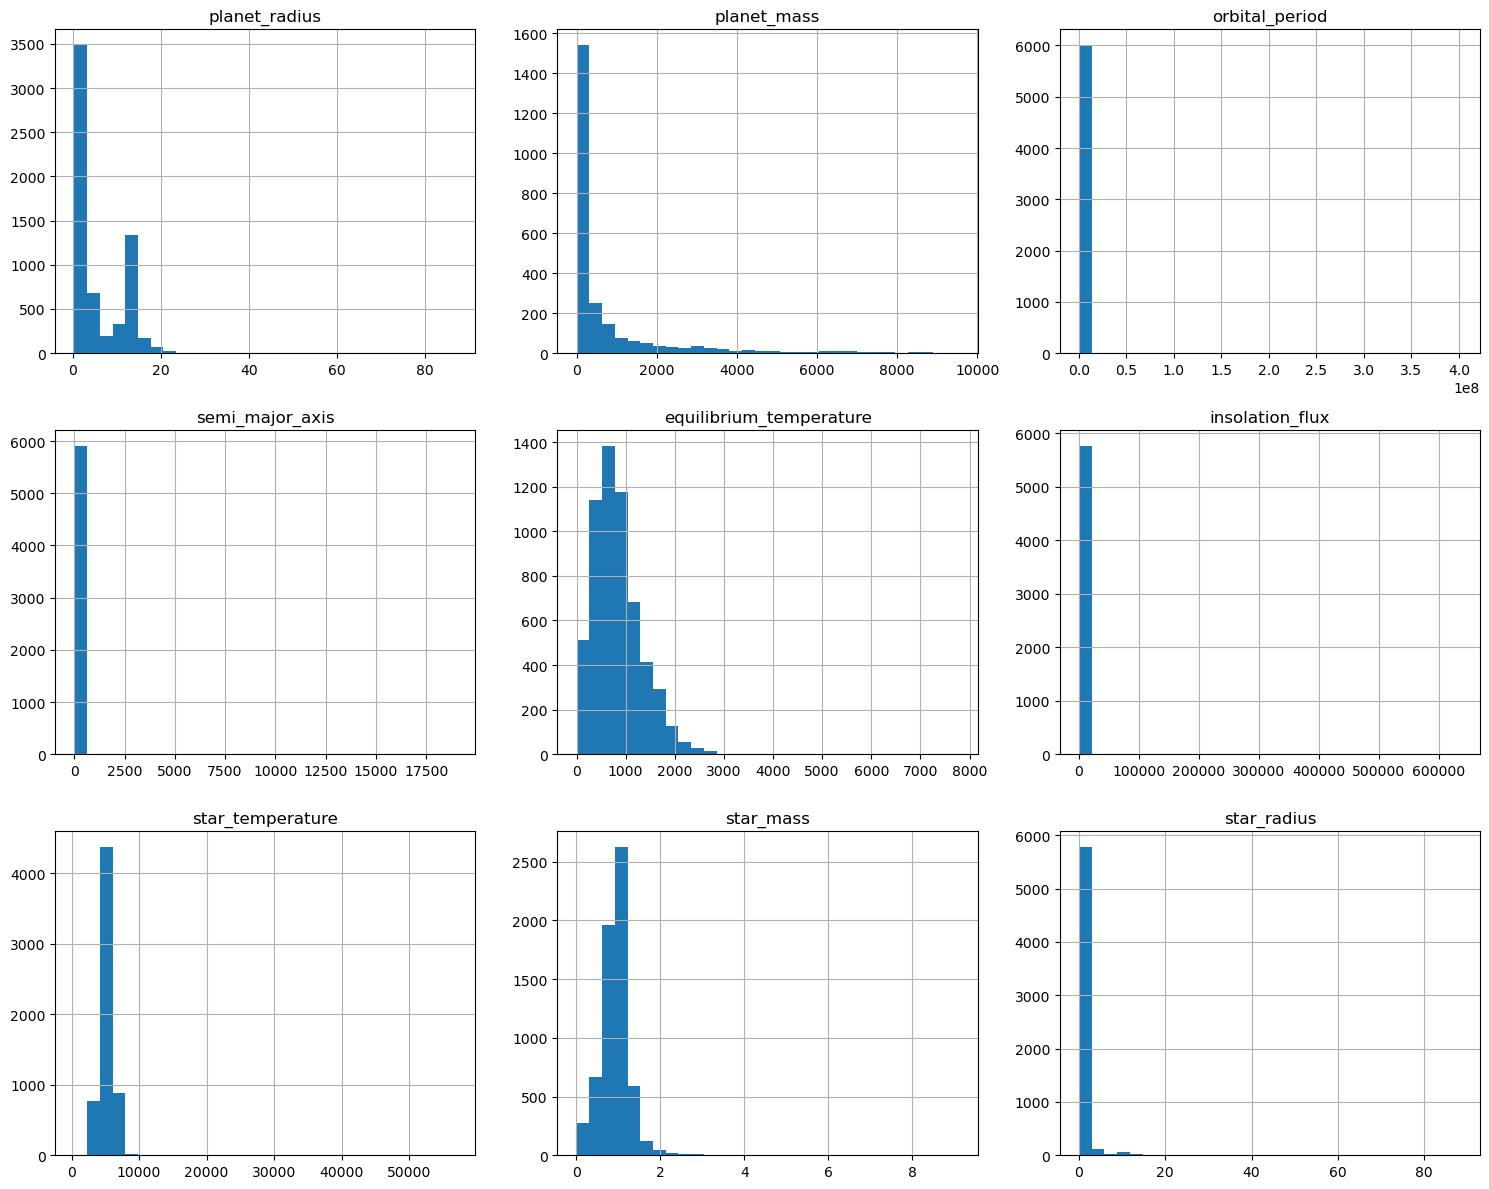

In [31]:
df[[
    "planet_radius",
    "planet_mass",
    "orbital_period",
    "semi_major_axis",
    "equilibrium_temperature",
    "insolation_flux",
    "star_temperature",
    "star_mass",
    "star_radius"
]].hist(figsize=(15, 12), bins=30)

plt.tight_layout()
plt.show()

In [32]:
df[[
    "planet_name",
    "planet_mass",
    "orbital_period",
    "semi_major_axis",
    "insolation_flux"
]].sort_values("orbital_period", ascending=False).head(10)

,planet_name,planet_mass,orbital_period,semi_major_axis,insolation_flux
5193,COCONUTS-2 b,2383.713052,4.020000e+08,7506.000,0.0000
6280,CFHTWIR-Oph 98 b,2479.061575,8.040000e+06,200.000,0.0000
2319,Oph 11 b,4449.620000,7.300000e+06,243.000,0.0000
1817,VHS J125601.92-125723.9 b,5085.254512,5.800000e+06,350.000,0.0000
4296,b Cen AB b,3464.329636,1.790000e+06,556.000,NaN
2181,HR 8799 b,2000.000000,1.700000e+05,68.000,0.0011
4963,HD 143811 AB b,1938.753283,1.170000e+05,63.000,0.0011
4595,HIP 81208 C b,4703.860424,1.041000e+05,23.040,NaN
5655,HD 105618 c,8419.592330,7.711407e+04,35.731,0.0012
4485,HD 62364 c,7923.462187,7.483995e+04,36.984,0.0020


In [33]:
df[[
    "planet_name",
    "planet_mass",
    "planet_radius",
    "equilibrium_temperature",
    "insolation_flux"
]].sort_values("insolation_flux", ascending=False).head(10)

,planet_name,planet_mass,planet_radius,equilibrium_temperature,insolation_flux
2230,KOI-55 b,0.440000,0.759000,7777.78,636352.1258
1996,KOI-55 c,0.655000,0.867000,6910.74,396618.3609
298,KELT-9 b,915.345812,21.700587,3921.00,44900.0000
4520,MASCARA-1 b,1175.971000,17.900742,2594.30,38711.5000
2779,KOI-13 b,2949.462400,16.948008,2550.00,25339.9010
5596,ZTF J1230-2655 b,7024.007795,13.787046,2949.65,17889.7450
400,TOI-2109 b,1595.498603,15.098497,3646.00,14429.0000
5927,TOI-1181 b,374.719692,17.026442,1942.12,14140.0000
3137,Kepler-1171 b,NaN,2.560000,2700.00,10171.0050
3858,WASP-33 b,665.218190,17.855937,2781.70,9392.0471


In [37]:
df.isna().sum()

planet_name                   0
host_star                     0
planet_radius                50
planet_mass                3912
orbital_period              346
semi_major_axis             430
equilibrium_temperature     530
insolation_flux             586
star_temperature            300
star_mass                     9
star_radius                 324
number_of_stars               0
number_of_planets             0
discovery_method              0
discovery_year                0
dtype: int64

In [38]:
df.shape

(6360, 15)

In [41]:
missing_percentage = (df.isna().mean()) * 100

missing_percentage.sort_values(ascending=False)

planet_mass                61.509434
insolation_flux             9.213836
equilibrium_temperature     8.333333
semi_major_axis             6.761006
orbital_period              5.440252
star_radius                 5.094340
star_temperature            4.716981
planet_radius               0.786164
star_mass                   0.141509
planet_name                 0.000000
host_star                   0.000000
number_of_stars             0.000000
number_of_planets           0.000000
discovery_method            0.000000
discovery_year              0.000000
dtype: float64

In [7]:
numeric_cols = [
    "planet_radius",
    "planet_mass",
    "orbital_period",
    "semi_major_axis",
    "equilibrium_temperature",
    "insolation_flux",
    "star_temperature",
    "star_mass",
    "star_radius",
    "number_of_stars",
    "number_of_planets"
]

corr = df[numeric_cols].corr()

corr

,planet_radius,planet_mass,orbital_period,semi_major_axis,equilibrium_temperature,insolation_flux,star_temperature,star_mass,star_radius,number_of_stars,number_of_planets
planet_radius,1.000000,0.338460,0.019249,0.055246,0.124624,0.002383,0.144540,0.289633,0.208149,0.180982,-0.245983
planet_mass,0.338460,1.000000,0.029039,0.172581,-0.081383,-0.014001,0.066686,0.137456,0.177066,0.018054,-0.164309
orbital_period,0.019249,0.029039,1.000000,0.996703,-0.007927,-0.000758,-0.015119,-0.021151,-0.003903,-0.003379,-0.009302
semi_major_axis,0.055246,0.172581,0.996703,1.000000,0.015778,-0.002459,-0.017962,-0.008093,-0.008041,0.030287,-0.027770
equilibrium_temperature,0.124624,-0.081383,-0.007927,0.015778,1.000000,0.304662,0.321436,0.262450,0.045212,0.014723,-0.173384
insolation_flux,0.002383,-0.014001,-0.000758,-0.002459,0.304662,1.000000,0.345136,0.000388,-0.005258,0.002057,-0.009018
star_temperature,0.144540,0.066686,-0.015119,-0.017962,0.321436,0.345136,1.000000,0.298606,-0.042912,0.053452,-0.031072
star_mass,0.289633,0.137456,-0.021151,-0.008093,0.262450,0.000388,0.298606,1.000000,0.455304,0.043462,-0.088399
star_radius,0.208149,0.177066,-0.003903,-0.008041,0.045212,-0.005258,-0.042912,0.455304,1.000000,0.006568,-0.074247
number_of_stars,0.180982,0.018054,-0.003379,0.030287,0.014723,0.002057,0.053452,0.043462,0.006568,1.000000,0.052444


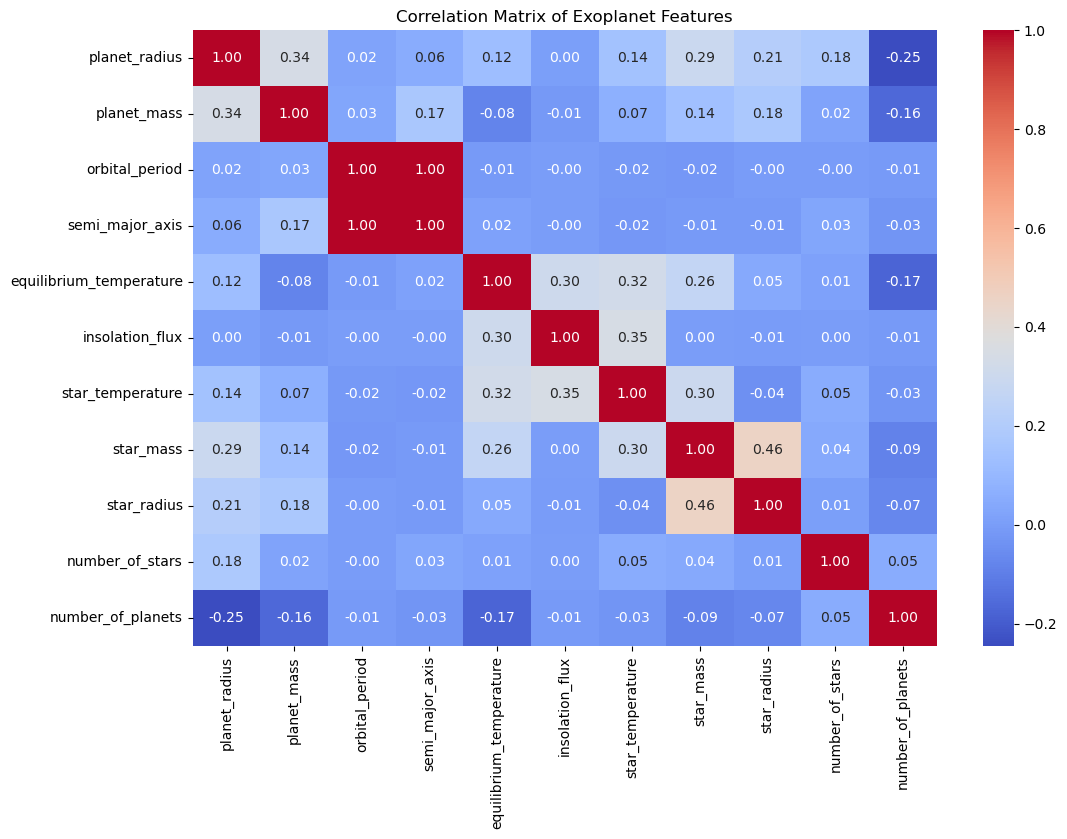

In [8]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix of Exoplanet Features")
plt.show()

In [10]:
features = [
    "planet_radius",
    "orbital_period",
    "semi_major_axis",
    "equilibrium_temperature",
    "insolation_flux",
    "star_temperature",
    "star_mass",
    "star_radius"
]

df_model = df[features].copy()

df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6360 entries, 0 to 6359
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   planet_radius            6310 non-null   float64
 1   orbital_period           6014 non-null   float64
 2   semi_major_axis          5930 non-null   float64
 3   equilibrium_temperature  5830 non-null   float64
 4   insolation_flux          5774 non-null   float64
 5   star_temperature         6060 non-null   float64
 6   star_mass                6351 non-null   float64
 7   star_radius              6036 non-null   float64
dtypes: float64(8)
memory usage: 397.6 KB


In [11]:
df_model.isna().sum()


planet_radius               50
orbital_period             346
semi_major_axis            430
equilibrium_temperature    530
insolation_flux            586
star_temperature           300
star_mass                    9
star_radius                324
dtype: int64

In [12]:
df_model.shape

(6360, 8)

In [13]:
for col in features:
    df_model[col] = df_model[col].fillna(df_model[col].median())

In [14]:
df_model.isna().sum()

planet_radius              0
orbital_period             0
semi_major_axis            0
equilibrium_temperature    0
insolation_flux            0
star_temperature           0
star_mass                  0
star_radius                0
dtype: int64

In [15]:
df_model["habitable"] = (
    (df_model["planet_radius"] >= 0.5) &
    (df_model["planet_radius"] <= 2.0) &
    (df_model["equilibrium_temperature"] >= 200) &
    (df_model["equilibrium_temperature"] <= 350) &
    (df_model["insolation_flux"] >= 0.25) &
    (df_model["insolation_flux"] <= 4.0)
).astype(int)

In [16]:
df_model["habitable"].value_counts()

habitable
0    6275
1      85
Name: count, dtype: int64

In [17]:
df_model["habitable"].value_counts(normalize=True) * 100

habitable
0    98.663522
1     1.336478
Name: proportion, dtype: float64

In [18]:
X = df_model[features]
y = df_model["habitable"]

In [19]:
X.shape, y.shape

((6360, 8), (6360,))

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [22]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

log_model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [23]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(
    max_depth=5,
    class_weight="balanced",
    random_state=42
)

tree_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


In [24]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)

rf_model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [25]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

models = {
    "Logistic Regression": (log_model, X_test_scaled),
    "Decision Tree": (tree_model, X_test),
    "Random Forest": (rf_model, X_test)
}

results = []

for name, (model, test_data) in models.items():
    pred = model.predict(test_data)
    prob = model.predict_proba(test_data)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "ROC_AUC": roc_auc_score(y_test, prob)
    })

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.963836,0.269841,1.0,0.425,0.995922
1,Decision Tree,1.000000,1.000000,1.0,1.000,1.000000
2,Random Forest,1.000000,1.000000,1.0,1.000,1.000000


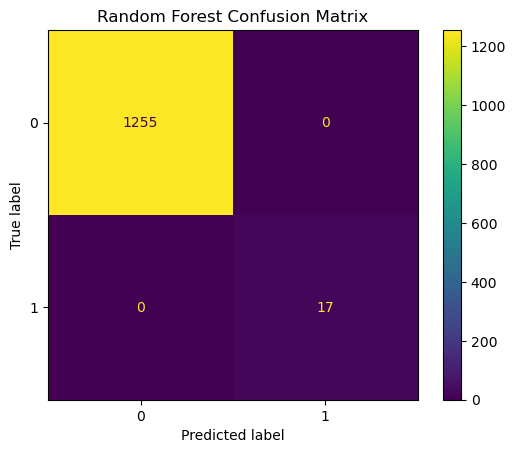

In [26]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_model.predict(X_test)
)

plt.title("Random Forest Confusion Matrix")
plt.show()

In [27]:
importance = pd.Series(
    rf_model.feature_importances_,
    index=features
).sort_values(ascending=False)

importance

equilibrium_temperature    0.257986
insolation_flux            0.221898
planet_radius              0.180395
star_radius                0.132827
star_temperature           0.090434
star_mass                  0.043143
orbital_period             0.042486
semi_major_axis            0.030830
dtype: float64

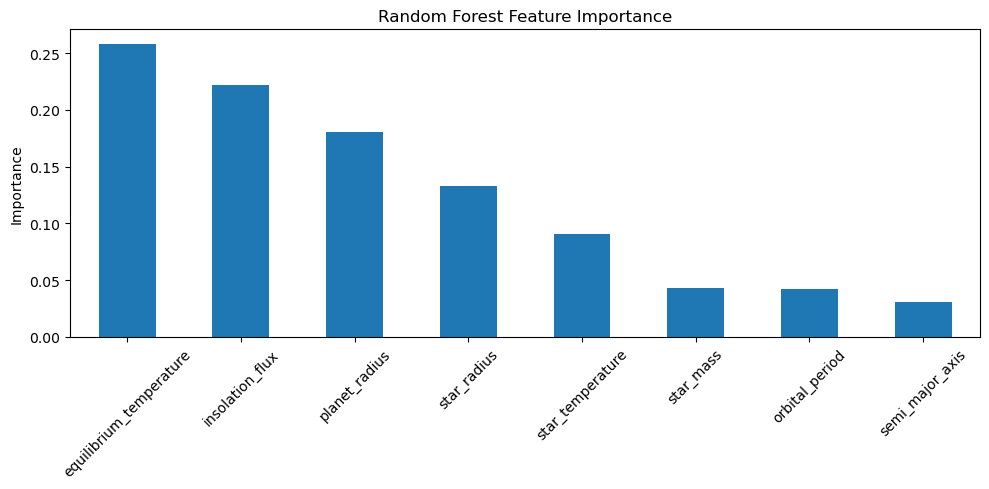

In [28]:
importance.plot(kind="bar", figsize=(10, 5))

plt.title("Random Forest Feature Importance")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

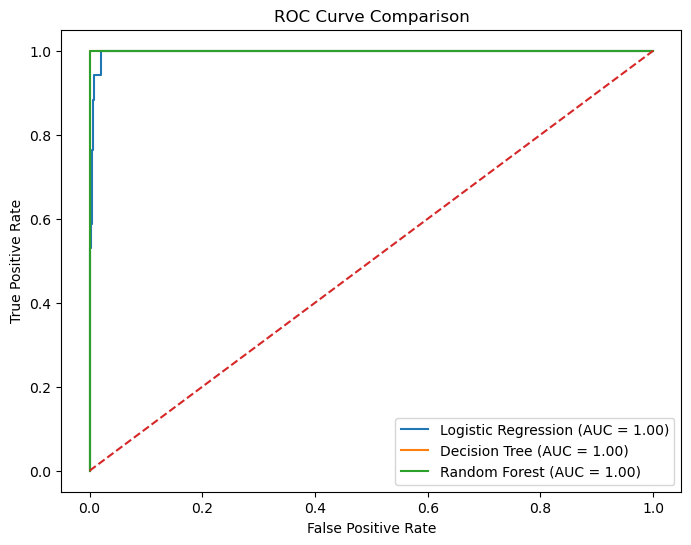

In [30]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8, 6))

models = {
    "Logistic Regression": (log_model, X_test_scaled),
    "Decision Tree": (tree_model, X_test),
    "Random Forest": (rf_model, X_test)
}

for name, (model, test_data) in models.items():
    probabilities = model.predict_proba(test_data)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probabilities)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [31]:
def predict_habitability(
    planet_radius,
    orbital_period,
    semi_major_axis,
    equilibrium_temperature,
    insolation_flux,
    star_temperature,
    star_mass,
    star_radius
):
    input_data = pd.DataFrame([[
        planet_radius,
        orbital_period,
        semi_major_axis,
        equilibrium_temperature,
        insolation_flux,
        star_temperature,
        star_mass,
        star_radius
    ]], columns=features)

    prediction = rf_model.predict(input_data)[0]
    probability = rf_model.predict_proba(input_data)[0][1]

    if prediction == 1:
        result = "Potentially Habitable"
    else:
        result = "Not Potentially Habitable"

    return result, probability

In [32]:
result, probability = predict_habitability(
    planet_radius=1.1,
    orbital_period=365,
    semi_major_axis=1.0,
    equilibrium_temperature=288,
    insolation_flux=1.0,
    star_temperature=5778,
    star_mass=1.0,
    star_radius=1.0
)

print("Prediction:", result)
print("Probability:", f"{probability:.2%}")

Prediction: Potentially Habitable
Probability: 56.00%


In [33]:
import joblib

joblib.dump(rf_model, "exoplanet_habitability_model.pkl")

['exoplanet_habitability_model.pkl']

In [34]:
joblib.dump(features, "features.pkl")

['features.pkl']